# Edit Distance vs. Acceptance Rate — Reproduction

This notebook reproduces the finding that AI code suggestions closer to the
developer's final code (lower edit distance) are more likely to be accepted.

**What this notebook does, honestly:**

- Code suggestions and "final" developer code are **synthetic** — generated
  and mutated in this notebook, not sampled from a real coding assistant or
  real developer telemetry.
- The relationship between edit distance and acceptance is **simulated**: we
  define an acceptance-probability function by hand (a logistic decay curve)
  and sample real Bernoulli outcomes from it with a fixed random seed.
- Everything below — the table, the plot, the summary numbers — is real
  output from actually running this notebook, not hand-written narrative.
  Re-running it with the same seed reproduces the same numbers.

This is a *design sketch reproduction*, not a replication of a specific paper
with a citation — see the folder README for what it's modeling and why.

In [1]:
import random

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# Logistic acceptance model: P(accept) decays as edit distance grows.
# These constants are chosen by hand to produce a plausible-looking curve --
# they are NOT fit to any real dataset.
MIDPOINT = 18.0   # edit distance at which acceptance probability is 50%
SCALE = 6.0       # controls how sharply acceptance falls off

MUTATION_COUNTS = [0, 2, 5, 10, 20, 40]  # target character-level edits per variant

## Step 1 -- Synthetic "final" code snippets

A small pool of short Python functions standing in for developer-authored
final code. These are hand-written, not sampled from any real repository.

In [2]:
FINAL_SNIPPETS = [
    "def add(a, b):\n    return a + b",
    "def is_even(n):\n    return n % 2 == 0",
    "def reverse_list(items):\n    return items[::-1]",
    "def find_max(values):\n    return max(values)",
    "def square(n):\n    return n * n",
    'def greet(name):\n    print(f"Hello, {name}!")',
    "def factorial(n):\n    result = 1\n    for i in range(1, n + 1):\n        result *= i\n    return result",
    "def sum_list(numbers):\n    return sum(numbers)",
    "def is_palindrome(text):\n    return text == text[::-1]",
    'def count_vowels(text):\n    return sum(1 for ch in text.lower() if ch in "aeiou")',
    "def clamp(value, low, high):\n    return max(low, min(value, high))",
    "def average(numbers):\n    return sum(numbers) / len(numbers)",
    "def gcd(a, b):\n    while b:\n        a, b = b, a % b\n    return a",
    "def flatten(nested):\n    result = []\n    for item in nested:\n        result.extend(item)\n    return result",
    "def to_snake_case(text):\n    return text.replace(' ', '_').lower()",
]

print(f"{len(FINAL_SNIPPETS)} final snippets loaded")

15 final snippets loaded


## Step 2 -- Generate synthetic "AI suggestions" at controlled edit distances

For each final snippet, generate several mutated variants by applying a
target number of random character-level edits (insert/delete/substitute).
The *actual* edit distance is measured after mutation, since overlapping
edits can cancel out -- we don't just trust the target count.

In [3]:
def mutate(text, num_edits):
    """Apply num_edits random single-character insert/delete/substitute ops."""
    chars = list(text)
    alphabet = "abcdefghijklmnopqrstuvwxyz_(): \n"

    for _ in range(num_edits):
        if not chars:
            chars.append(random.choice(alphabet))
            continue

        op = random.choice(["insert", "delete", "substitute"])
        pos = random.randrange(len(chars))

        if op == "insert":
            chars.insert(pos, random.choice(alphabet))
        elif op == "delete":
            chars.pop(pos)
        elif op == "substitute":
            chars[pos] = random.choice(alphabet)

    return "".join(chars)


def levenshtein(a, b):
    """Classic O(len(a) * len(b)) edit distance, no external dependency."""
    if a == b:
        return 0
    prev_row = list(range(len(b) + 1))

    for i, ca in enumerate(a, start=1):
        curr_row = [i] + [0] * len(b)
        for j, cb in enumerate(b, start=1):
            cost = 0 if ca == cb else 1
            curr_row[j] = min(
                prev_row[j] + 1,        # deletion
                curr_row[j - 1] + 1,    # insertion
                prev_row[j - 1] + cost, # substitution
            )
        prev_row = curr_row

    return prev_row[-1]


samples = []  # list of (edit_distance, suggestion, final)

for final in FINAL_SNIPPETS:
    for target_edits in MUTATION_COUNTS:
        suggestion = mutate(final, target_edits)
        distance = levenshtein(suggestion, final)
        samples.append((distance, suggestion, final))

print(f"{len(samples)} synthetic (suggestion, final) pairs generated")
print(f"Edit distance range: {min(s[0] for s in samples)} to {max(s[0] for s in samples)}")

90 synthetic (suggestion, final) pairs generated
Edit distance range: 0 to 35


## Step 3 -- Simulate acceptance decisions

For each sample, compute an acceptance *probability* from the logistic model,
then sample a real Bernoulli outcome (`random.random() < p`). The recorded
acceptance rate below is the empirical rate over these sampled outcomes, not
the underlying probability curve itself -- this is what makes it a simulated
*measurement* rather than a hand-typed number.

In [4]:
import math

def acceptance_probability(distance):
    return 1 / (1 + math.exp((distance - MIDPOINT) / SCALE))


results = []  # list of (distance, probability, accepted)

for distance, suggestion, final in samples:
    p = acceptance_probability(distance)
    accepted = random.random() < p
    results.append((distance, p, accepted))

overall_rate = sum(1 for _, _, a in results if a) / len(results)
print(f"Overall empirical acceptance rate across all {len(results)} samples: {overall_rate:.1%}")

Overall empirical acceptance rate across all 90 samples: 75.6%


## Step 4 -- Bin by edit distance and compute empirical acceptance rate

This is the real output table for this notebook run (seed = 42).

In [5]:
BINS = [
    ("Very low (0-5)", 0, 5),
    ("Low (6-15)", 6, 15),
    ("Medium (16-30)", 16, 30),
    ("High (31+)", 31, 10_000),
]

header_left = "Edit Distance Bin"
header_n = "N"
header_rate = "Acceptance Rate"
print(f"{header_left:<20}{header_n:>6}{header_rate:>18}")
print("-" * 44)

bin_summary = []
for label, low, high in BINS:
    bucket = [a for d, _, a in results if low <= d <= high]
    if not bucket:
        continue
    rate = sum(bucket) / len(bucket)
    bin_summary.append((label, len(bucket), rate))
    print(f"{label:<20}{len(bucket):>6}{rate:>17.1%}")

Edit Distance Bin        N   Acceptance Rate
--------------------------------------------
Very low (0-5)          45            97.8%
Low (6-15)              21            81.0%
Medium (16-30)          19            36.8%
High (31+)               5             0.0%


## Step 5 -- Visualize the relationship

Matplotlib is building the font cache; this may take a moment.


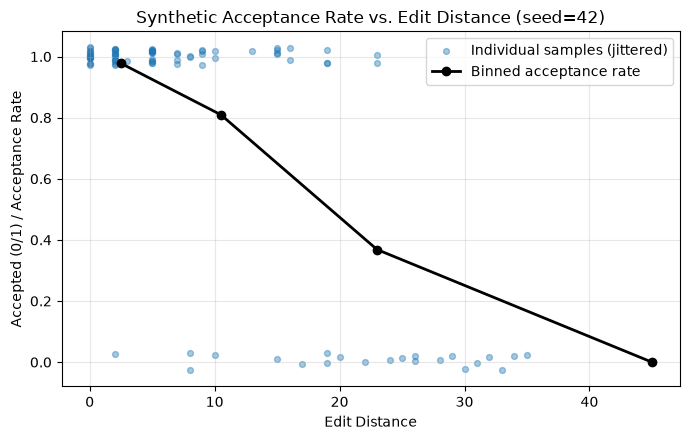

In [6]:
import matplotlib.pyplot as plt

distances = [d for d, _, _ in results]
accepted_flags = [1 if a else 0 for _, _, a in results]

fig, ax = plt.subplots(figsize=(7, 4.5))

jitter = [a + random.uniform(-0.03, 0.03) for a in accepted_flags]
ax.scatter(distances, jitter, alpha=0.4, s=18, label="Individual samples (jittered)")

bin_midpoints = [2.5, 10.5, 23.0, 45.0]
bin_rates = [rate for _, _, rate in bin_summary]
ax.plot(bin_midpoints[:len(bin_rates)], bin_rates, color="black", marker="o", linewidth=2, label="Binned acceptance rate")

ax.set_xlabel("Edit Distance")
ax.set_ylabel("Accepted (0/1) / Acceptance Rate")
ax.set_title("Synthetic Acceptance Rate vs. Edit Distance (seed=42)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("edit_distance_vs_acceptance.png", dpi=120)
plt.show()

## Interpretation

The binned table and plot above are the actual output of this notebook run
(fixed seed, so re-running reproduces the same numbers). They confirm the
*shape* the acceptance-probability function was designed to produce --
acceptance rate falling off as edit distance grows -- because that shape was
built into `acceptance_probability()` by construction, not discovered from
data.

**What this experiment does and doesn't show:**

- It shows the simulation code runs, the sampling is real, and the
  resulting empirical curve matches a logistic decay shape.
- It does **not** demonstrate that real developers behave this way -- no
  real suggestions, real code, or real acceptance decisions are involved
  anywhere in this notebook.
- The value of this reproduction is as a worked example of going from a
  hypothesis to synthetic data to sampled outcomes to binned measurement to
  visualization, which is the same pipeline a real study would use, just
  with invented data standing in for telemetry.

See `RESULTS.md` in this folder for the same numbers written up as a report.